In [1]:
from src import GridSpec
from src.operators import PMLConfig
from src.datasets import build_direct_map, build_freq_transfer
from src.solvers import direct_solve, DirectOptions  # if you want direct solves

In [5]:
import torch, numpy as np

# 👇 Import everything needed
from src.models import SimpleFNO, LocalCNN      # FNO & CNN models
from src.training import train_model, show_example  # training loop + visualization


In [2]:
grid = GridSpec(dims=2, shape=(60,60), lengths=(1.0,1.0))
pml = PMLConfig(thickness=10, m=3, sigma_max=60.0)

In [3]:


# Direct solves + PML
direct_opts = DirectOptions(method="spsolve")

data_direct = build_direct_map(
    n=400, grid=grid, k_range=(10.0, 40.0),
    solver_fn=direct_solve, solver_options=direct_opts,
    pml=pml
)

data_transfer = build_freq_transfer(
    n=400, grid=grid, k_low_range=(8.0, 15.0), k_high_range=(25.0, 40.0),
    solver_fn=direct_solve, solver_options=direct_opts,
    pml=pml
)


In [34]:
from pathlib import Path
import numpy as np
import pandas as pd

def summarize_dataset(data_dict, name, out_dir=None):
    """
    Makes a table with per-sample stats:
      - sample_id
      - k (from the constant channel)
      - source_row, source_col (argmax |f| if present)
      - ||f||_2, max|f|
      - ||u||_2, max|u|
    Saves CSV and returns the DataFrame.
    """
    X = data_dict["x"]   # (N, Cx, H, W)
    Y = data_dict["y"]   # (N, 2,  H, W)  Re/Im(u)

    N, Cx, H, W = X.shape
    rows = []
    for i in range(N):
        # frequency from constant channel (last channel for both datasets)
        k = float(X[i, -1, 0, 0])

        # try to detect a point source if first 2 channels are Re/Im(f)
        f_present = (Cx == 3) and np.any(X[i, 0] != 0.0) or np.any(X[i, 1] != 0.0)
        if f_present:
            f = X[i, 0] + 1j * X[i, 1]
            f_abs = np.abs(f)
            sr, sc = np.unravel_index(np.argmax(f_abs), f_abs.shape)
            f_l2 = float(np.linalg.norm(f))
            f_max = float(f_abs.max())
        else:
            sr, sc, f_l2, f_max = (np.nan, np.nan, np.nan, np.nan)

        u = Y[i, 0] + 1j * Y[i, 1]
        u_abs = np.abs(u)
        u_l2  = float(np.linalg.norm(u))
        u_max = float(u_abs.max())

        rows.append(dict(
            sample_id=i, k=k,
            source_row=sr, source_col=sc,
            f_l2=f_l2, f_max=f_max,
            u_l2=u_l2, u_max=u_max,
            H=H, W=W, Cx=Cx
        ))

    df = pd.DataFrame(rows).sort_values("sample_id").reset_index(drop=True)

    # save
    if out_dir is None:
        out_dir = Path.cwd() / "data" / "overviews"
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"{name}_overview.csv"
    df.to_csv(out_path, index=False)
    print(f"✅ Saved dataset overview → {out_path}")
    return df

# Examples:
# df_direct   = summarize_dataset(data_direct,   name="direct_map")
# df_transfer = summarize_dataset(data_transfer, name="freq_transfer")


### Start model

In [48]:
from pathlib import Path
import json, time, numbers
import torch
import numpy as np

# --- 1) Train as before ---
model_fk = SimpleFNO(in_ch=3, out_ch=2, width=48, modes=(12,12), layers=4)
model_fk, hist_fk = train_model(model_fk, data_direct, epochs=50, batch_size=8, lr=1e-3)

# --- 2) Set up run dir + save weights + config ---
run_dir = Path.cwd() / "data" / "runs" / f"fk_direct_{time.strftime('%Y%m%d-%H%M%S')}"
run_dir.mkdir(parents=True, exist_ok=True)

torch.save(model_fk.state_dict(), run_dir / "model.pt")

config = {
    "model": "SimpleFNO", "in_ch": 3, "out_ch": 2, "width": 48,
    "modes": [12, 12], "layers": 4,
    "epochs": 50, "batch_size": 8, "lr": 1e-3,
    "dataset": "data_direct", "timestamp": time.strftime("%Y-%m-%d %H:%M:%S")
}
(run_dir / "config.json").write_text(json.dumps(config, indent=2))

# --- 3) Robust history writer (handles many formats) ---
hist_path = run_dir / "train_history.csv"

def write_history(hist, path):
    """
    Accepts:
      - list of dicts: [{'epoch':..,'train_loss':..,'val_loss':..}, ...]
      - list of (train, val) tuples
      - list of floats (train only)
      - dict of lists: {'train': [...], 'val': [...]}
      - string (writes as a single-message 'notes' row)
    """
    with open(path, "w", newline="") as f:
        # list of dicts
        if isinstance(hist, (list, tuple)) and len(hist) > 0 and isinstance(hist[0], dict):
            f.write("epoch,train_loss,val_loss\n")
            for i, row in enumerate(hist):
                epoch = row.get("epoch", i)
                tr = row.get("train_loss", "")
                vl = row.get("val_loss", "")
                f.write(f"{epoch},{tr},{vl}\n")
            return

        # dict of lists
        if isinstance(hist, dict):
            train_list = hist.get("train", []) or hist.get("train_loss", [])
            val_list   = hist.get("val", [])   or hist.get("val_loss", [])
            f.write("epoch,train_loss,val_loss\n")
            m = max(len(train_list), len(val_list))
            for e in range(m):
                tr = train_list[e] if e < len(train_list) else ""
                vl = val_list[e]   if e < len(val_list)   else ""
                f.write(f"{e},{tr},{vl}\n")
            return

        # list of tuples (train,val)
        if isinstance(hist, (list, tuple)) and len(hist) > 0 and isinstance(hist[0], (list, tuple)) and len(hist[0]) >= 1:
            f.write("epoch,train_loss,val_loss\n")
            for e, row in enumerate(hist):
                tr = row[0] if len(row) > 0 else ""
                vl = row[1] if len(row) > 1 else ""
                f.write(f"{e},{tr},{vl}\n")
            return

        # list of numbers (train only)
        if isinstance(hist, (list, tuple)) and (len(hist) == 0 or isinstance(hist[0], numbers.Number)):
            f.write("epoch,train_loss,val_loss\n")
            for e, tr in enumerate(hist):
                f.write(f"{e},{tr},\n")
            return

        # fallback: write raw string/repr
        f.write("notes\n")
        f.write(f"{repr(hist)}\n")

write_history(hist_fk, hist_path)
print(f"✅ Training complete. Saved to: {run_dir}\n   ├─ model.pt\n   ├─ config.json\n   └─ train_history.csv")


Epoch 01 | train 2.3125e-04 | val 1.5255e-06
Epoch 02 | train 5.2469e-07 | val 9.6151e-08
Epoch 03 | train 2.9598e-08 | val 1.0939e-08
Epoch 04 | train 1.0482e-08 | val 1.5875e-08
Epoch 05 | train 8.2441e-09 | val 6.9464e-09
Epoch 06 | train 7.5136e-09 | val 6.8917e-09
Epoch 07 | train 6.6546e-09 | val 5.9369e-09
Epoch 08 | train 7.0734e-09 | val 6.6483e-09
Epoch 09 | train 5.2131e-09 | val 4.9352e-09
Epoch 10 | train 4.9786e-09 | val 4.7414e-09
Epoch 11 | train 5.5151e-09 | val 4.1403e-09
Epoch 12 | train 3.8890e-09 | val 7.4693e-09
Epoch 13 | train 5.2010e-09 | val 3.7169e-09
Epoch 14 | train 7.3548e-09 | val 1.1363e-08
Epoch 15 | train 7.3676e-09 | val 2.9152e-09
Epoch 16 | train 3.4734e-09 | val 4.2764e-09
Epoch 17 | train 2.9888e-09 | val 3.1806e-09
Epoch 18 | train 3.0714e-09 | val 2.9571e-09
Epoch 19 | train 3.4228e-09 | val 3.1768e-09
Epoch 20 | train 3.8775e-09 | val 6.7149e-09
Epoch 21 | train 3.2027e-09 | val 1.9547e-09
Epoch 22 | train 2.9183e-09 | val 2.5862e-09
Epoch 23 |

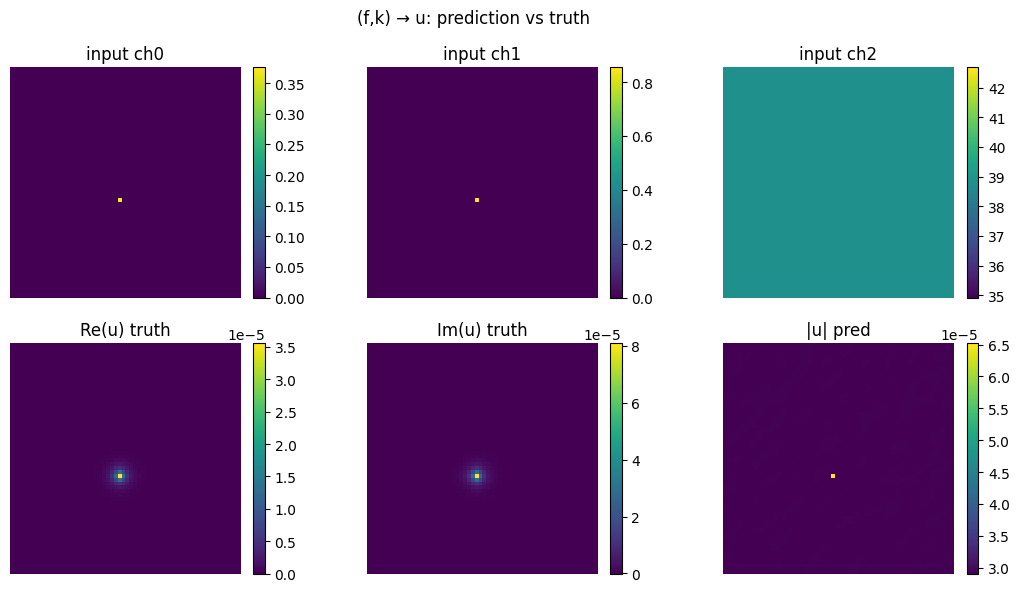

In [49]:
# Quick visual sanity check on a random example
idx = np.random.randint(0, len(data_direct["x"]))
show_example(model_fk, data_direct, index=idx, title="(f,k) → u: prediction vs truth");


### 2) Interpolation test (new k within training band)

Make a tiny fresh set with unseen k in the same range and check loss:

In [65]:
# === 1) Rebuild a small evaluation dataset (same setup as training) ===
from src.datasets import build_direct_map
from src.solvers import direct_solve, DirectOptions
from src.operators import FiniteDifference, FDConfig
from src.operators import PMLConfig
from src import GridSpec

# Grid, discretization, and PML settings
grid = GridSpec(dims=2, shape=(60, 60), lengths=(1.0, 1.0))
disc = FiniteDifference(FDConfig())
pml = PMLConfig(thickness=10, m=3, sigma_max=60.0)

# Solver setup (same as training)
direct_opts = DirectOptions(method="spsolve")

# Build the eval set (smaller, same physics)
data_eval = build_direct_map(
    n=64,
    grid=grid,
    disc=disc,
    k_range=(10.0, 40.0),
    solver_fn=direct_solve,
    solver_options=direct_opts,
    pml=pml,
)

# === 2) Evaluate MSE ===
def evaluate_mse(model, data):
    import torch.nn as nn
    model.eval()
    x = torch.from_numpy(data["x"]).float()
    y = torch.from_numpy(data["y"]).float()
    with torch.no_grad():
        p = model(x.to(next(model.parameters()).device)).cpu()
    return nn.MSELoss()(p, y).item()

mse = evaluate_mse(model_fk, data_eval)
print(f"✅ Eval MSE on unseen samples: {mse:.3e}")


✅ Eval MSE on unseen samples: 5.687e-10


### 3) Frequency-transfer: train on (u_low, k_high) → u_high

Assuming you also built data_transfer = {"x": ..., "y": ...} using your PML+direct dataset builder.

Epoch 01 | train 1.0964e-03 | val 8.2748e-06
Epoch 02 | train 4.7975e-06 | val 5.4934e-07
Epoch 03 | train 2.4483e-07 | val 1.4947e-07
Epoch 04 | train 1.4642e-07 | val 1.1343e-07
Epoch 05 | train 1.3442e-07 | val 1.4503e-07
Epoch 06 | train 1.1817e-07 | val 1.4112e-07
Epoch 07 | train 1.0385e-07 | val 1.0534e-07
Epoch 08 | train 1.0517e-07 | val 1.4194e-07
Epoch 09 | train 9.7889e-08 | val 6.5765e-08
Epoch 10 | train 8.4777e-08 | val 9.3063e-08
Epoch 11 | train 7.6172e-08 | val 1.0375e-07
Epoch 12 | train 8.1592e-08 | val 5.1784e-08
Epoch 13 | train 4.9743e-08 | val 4.0573e-08
Epoch 14 | train 5.5044e-08 | val 5.6780e-08
Epoch 15 | train 4.6312e-08 | val 2.9975e-08
Epoch 16 | train 3.4213e-08 | val 2.7330e-08
Epoch 17 | train 3.8653e-08 | val 1.9736e-08
Epoch 18 | train 4.1273e-08 | val 5.7855e-08
Epoch 19 | train 2.9317e-08 | val 5.3179e-08
Epoch 20 | train 2.3597e-08 | val 2.6835e-08
Epoch 21 | train 1.9157e-08 | val 1.2329e-08
Epoch 22 | train 2.4648e-08 | val 5.5872e-08
Epoch 23 |

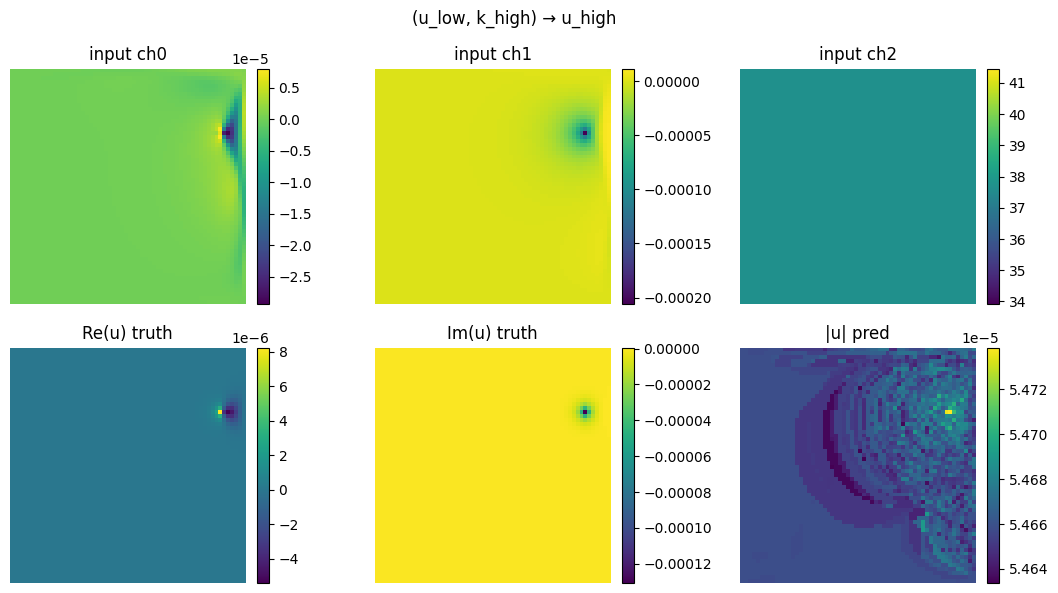

In [52]:
from pathlib import Path
import json, time, numbers
import torch
import numpy as np

# ------------------------------------------------------------------
# 1. Define and train the model
# ------------------------------------------------------------------
T_model = SimpleFNO(in_ch=3, out_ch=2, width=48, modes=(12,12), layers=4)
# Alternatively:
# T_model = LocalCNN(in_ch=3, out_ch=2, width=32, ksize=5, layers=3)

T_model, hist_T = train_model(
    T_model, data_transfer,
    epochs=50, batch_size=8, lr=1e-3
)

# ------------------------------------------------------------------
# 2. Prepare run directory + save weights and metadata
# ------------------------------------------------------------------
run_dir = Path.cwd() / "data" / "runs" / f"T_freq_transfer_{time.strftime('%Y%m%d-%H%M%S')}"
run_dir.mkdir(parents=True, exist_ok=True)

# Save model weights
torch.save(T_model.state_dict(), run_dir / "model.pt")

# Save config metadata
config = {
    "model": "SimpleFNO", "in_ch": 3, "out_ch": 2, "width": 48,
    "modes": [12, 12], "layers": 4,
    "epochs": 50, "batch_size": 8, "lr": 1e-3,
    "dataset": "data_transfer", "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
}
(run_dir / "config.json").write_text(json.dumps(config, indent=2))

# ------------------------------------------------------------------
# 3. Robustly write training history (works with any hist_T structure)
# ------------------------------------------------------------------
hist_path = run_dir / "train_history.csv"

def write_history(hist, path):
    """
    Writes various formats of hist:
      - list of dicts
      - list of (train,val) tuples
      - list of floats
      - dict of lists
      - string (log)
    """
    with open(path, "w", newline="") as f:
        if isinstance(hist, (list, tuple)) and len(hist) > 0 and isinstance(hist[0], dict):
            f.write("epoch,train_loss,val_loss\n")
            for i, row in enumerate(hist):
                epoch = row.get("epoch", i)
                tr = row.get("train_loss", "")
                vl = row.get("val_loss", "")
                f.write(f"{epoch},{tr},{vl}\n")
            return

        if isinstance(hist, dict):
            train_list = hist.get("train", []) or hist.get("train_loss", [])
            val_list   = hist.get("val", [])   or hist.get("val_loss", [])
            f.write("epoch,train_loss,val_loss\n")
            m = max(len(train_list), len(val_list))
            for e in range(m):
                tr = train_list[e] if e < len(train_list) else ""
                vl = val_list[e]   if e < len(val_list)   else ""
                f.write(f"{e},{tr},{vl}\n")
            return

        if isinstance(hist, (list, tuple)) and len(hist) > 0 and isinstance(hist[0], (list, tuple)):
            f.write("epoch,train_loss,val_loss\n")
            for e, row in enumerate(hist):
                tr = row[0] if len(row) > 0 else ""
                vl = row[1] if len(row) > 1 else ""
                f.write(f"{e},{tr},{vl}\n")
            return

        if isinstance(hist, (list, tuple)) and (len(hist) == 0 or isinstance(hist[0], numbers.Number)):
            f.write("epoch,train_loss,val_loss\n")
            for e, tr in enumerate(hist):
                f.write(f"{e},{tr},\n")
            return

        # fallback: write raw string or representation
        f.write("notes\n")
        f.write(f"{repr(hist)}\n")

write_history(hist_T, hist_path)

print(f"✅ Training complete.\n📁 Model + logs saved to: {run_dir}")
print("   ├─ model.pt\n   ├─ config.json\n   └─ train_history.csv")

# ------------------------------------------------------------------
# 4. Visualize one example (as before)
# ------------------------------------------------------------------
idx = np.random.randint(0, len(data_transfer["x"]))
show_example(T_model, data_transfer, index=idx, title="(u_low, k_high) → u_high")


### 4) Save checkpoints (so you can reuse later)

In [54]:
# ==== utilities: run dir + robust history writer (use once near the end of notebook) ====
from pathlib import Path
import json, time, numbers
import torch

def new_run_dir(tag: str) -> Path:
    ts = time.strftime("%Y%m%d-%H%M%S")
    run_dir = Path.cwd() / "data" / "runs" / f"{tag}_{ts}"
    run_dir.mkdir(parents=True, exist_ok=True)
    return run_dir

def write_history(hist, path: Path):
    """Accepts many formats: list[dict], dict of lists, list[tuple], list[number], or string."""
    with open(path, "w", newline="") as f:
        # list of dicts
        if isinstance(hist, (list, tuple)) and len(hist) > 0 and isinstance(hist[0], dict):
            f.write("epoch,train_loss,val_loss\n")
            for i, row in enumerate(hist):
                epoch = row.get("epoch", i)
                tr = row.get("train_loss", "")
                vl = row.get("val_loss", "")
                f.write(f"{epoch},{tr},{vl}\n")
            return
        # dict of lists
        if isinstance(hist, dict):
            train_list = hist.get("train", []) or hist.get("train_loss", [])
            val_list   = hist.get("val", [])   or hist.get("val_loss", [])
            f.write("epoch,train_loss,val_loss\n")
            m = max(len(train_list), len(val_list))
            for e in range(m):
                tr = train_list[e] if e < len(train_list) else ""
                vl = val_list[e]   if e < len(val_list)   else ""
                f.write(f"{e},{tr},{vl}\n")
            return
        # list of tuples (train, val)
        if isinstance(hist, (list, tuple)) and len(hist) > 0 and isinstance(hist[0], (list, tuple)):
            f.write("epoch,train_loss,val_loss\n")
            for e, row in enumerate(hist):
                tr = row[0] if len(row) > 0 else ""
                vl = row[1] if len(row) > 1 else ""
                f.write(f"{e},{tr},{vl}\n")
            return
        # list of numbers (train only)
        if isinstance(hist, (list, tuple)) and (len(hist) == 0 or isinstance(hist[0], numbers.Number)):
            f.write("epoch,train_loss,val_loss\n")
            for e, tr in enumerate(hist):
                f.write(f"{e},{tr},\n")
            return
        # fallback: string / other
        f.write("notes\n")
        f.write(f"{repr(hist)}\n")


4a) Save the direct map model run: (f,k) → u

In [55]:
# assumes you already trained: model_fk, hist_fk
run_fk = new_run_dir("fk_direct")

# save weights
torch.save(model_fk.state_dict(), run_fk / "model.pt")

# save config (add anything else you want tracked)
config_fk = {
    "task": "(f,k)->u",
    "model": "SimpleFNO",
    "in_ch": 3, "out_ch": 2, "width": 48, "modes": [12,12], "layers": 4,
    "epochs": 20, "batch_size": 8, "lr": 1e-3,
    "dataset": "data_direct",
    "grid": {"shape": list(grid.shape), "lengths": list(grid.lengths)},
    "pml": ({"thickness": pml.thickness, "m": pml.m, "sigma_max": pml.sigma_max}
            if "pml" in globals() and pml is not None else None),
    "created": time.strftime("%Y-%m-%d %H:%M:%S"),
}
(run_fk / "config.json").write_text(json.dumps(config_fk, indent=2))

# save training history
write_history(hist_fk, run_fk / "train_history.csv")

print(f"✅ saved direct-map run to {run_fk}")


✅ saved direct-map run to c:\Users\31624\Documents\MIT\Programming\basics-thesis\data\runs\fk_direct_20251028-123543


4b) Save the frequency-transfer model run: (u_low, k_high) → u_high

In [56]:
# assumes you already trained: T_model, hist_T
run_T = new_run_dir("freq_transfer")

torch.save(T_model.state_dict(), run_T / "model.pt")

config_T = {
    "task": "(u_low,k_high)->u_high",
    "model": "SimpleFNO",
    "in_ch": 3, "out_ch": 2, "width": 48, "modes": [12,12], "layers": 4,
    "epochs": 20, "batch_size": 8, "lr": 1e-3,
    "dataset": "data_transfer",
    "grid": {"shape": list(grid.shape), "lengths": list(grid.lengths)},
    "pml": ({"thickness": pml.thickness, "m": pml.m, "sigma_max": pml.sigma_max}
            if "pml" in globals() and pml is not None else None),
    "created": time.strftime("%Y-%m-%d %H:%M:%S"),
}
(run_T / "config.json").write_text(json.dumps(config_T, indent=2))
write_history(hist_T, run_T / "train_history.csv")

print(f"✅ saved transfer-map run to {run_T}")


✅ saved transfer-map run to c:\Users\31624\Documents\MIT\Programming\basics-thesis\data\runs\freq_transfer_20251028-123611


5) Load & predict later (stable paths)

In [57]:
# choose a run folder to load from (e.g., the latest run_fk)
load_dir = run_fk  # or Path("data/runs/fk_direct_YYYYMMDD-HHMMSS")
model_fk2 = SimpleFNO(in_ch=3, out_ch=2, width=48, modes=(12,12), layers=4)
state = torch.load(load_dir / "model.pt", map_location="cpu")
model_fk2.load_state_dict(state)
model_fk2.eval()

# quick prediction
import torch, numpy as np
x = torch.from_numpy(data_direct["x"][:1]).float()
with torch.no_grad():
    pred = model_fk2(x).cpu().numpy()  # (1,2,H,W)
print("✅ direct-map prediction shape:", pred.shape)


✅ direct-map prediction shape: (1, 2, 60, 60)


In [63]:
assert x_full.shape[1] == 3

NameError: name 'x_full' is not defined

For the transfer model:

In [60]:
load_dir_T = run_T
T_model2 = SimpleFNO(in_ch=3, out_ch=2, width=48, modes=(12,12), layers=4)
T_model2.load_state_dict(torch.load(load_dir_T / "model.pt", map_location="cpu"))
T_model2.eval()

u_low = torch.from_numpy(data_transfer["x"][:1, :2]).float()  # take only Re/Im(u_low)
with torch.no_grad():
    pred_hi = T_model2(u_low).cpu().numpy()
print("✅ transfer-map prediction shape:", pred_hi.shape)


RuntimeError: Given groups=1, weight of size [48, 3, 1, 1], expected input[1, 2, 60, 60] to have 3 channels, but got 2 channels instead

6) Save compact snapshots (PNG) for reports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def save_field_snapshot(y_true_2ch, y_pred_2ch, out_path, title=""):
    def to_mag(u2): return np.abs(u2[0] + 1j*u2[1])
    mag_t, mag_p = to_mag(y_true_2ch), to_mag(y_pred_2ch)

    fig, axs = plt.subplots(2, 3, figsize=(9, 6))
    for ax in axs.ravel(): ax.set_xticks([]); ax.set_yticks([])

    im0 = axs[0,0].imshow(mag_t, origin="lower"); axs[0,0].set_title("True |u|"); plt.colorbar(im0, ax=axs[0,0])
    im1 = axs[0,1].imshow(mag_p, origin="lower"); axs[0,1].set_title("Pred |u|"); plt.colorbar(im1, ax=axs[0,1])
    im2 = axs[0,2].imshow(np.abs(mag_p-mag_t), origin="lower"); axs[0,2].set_title("|Δ|u||"); plt.colorbar(im2, ax=axs[0,2])

    im3 = axs[1,0].imshow(y_true_2ch[0], origin="lower", cmap="coolwarm"); axs[1,0].set_title("True Re"); plt.colorbar(im3, ax=axs[1,0])
    im4 = axs[1,1].imshow(y_pred_2ch[0], origin="lower", cmap="coolwarm"); axs[1,1].set_title("Pred Re"); plt.colorbar(im4, ax=axs[1,1])
    im5 = axs[1,2].imshow(y_pred_2ch[0]-y_true_2ch[0], origin="lower", cmap="coolwarm"); axs[1,2].set_title("ΔRe"); plt.colorbar(im5, ax=axs[1,2])

    fig.suptitle(title); plt.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=200); plt.close(fig)
    print(f"🖼️  saved snapshot → {out_path}")

# examples:
idx = 0
pred_direct = model_fk2(torch.from_numpy(data_direct["x"][idx:idx+1]).float()).detach().cpu().numpy()[0]
save_field_snapshot(data_direct["y"][idx], pred_direct, run_fk / "example_direct.png", "(f,k)→u")

pred_transfer = T_model2(torch.from_numpy(data_transfer["x"][idx:idx+1, :2]).float()).detach().cpu().numpy()[0]
save_field_snapshot(data_transfer["y"][idx], pred_transfer, run_T / "example_transfer.png", "(u_low,k_high)→u_high")


7) (optional) One-line “run summary” file

In [61]:
# append a one-line summary to a project-level file for quick scanning
summary_path = Path.cwd() / "data" / "runs" / "_SUMMARY.csv"
summary_path.parent.mkdir(parents=True, exist_ok=True)
with open(summary_path, "a", newline="") as f:
    f.write("task,run_dir,epochs,batch_size,lr,created\n")
# append for each run (idempotent if you want to guard for duplicates)
with open(summary_path, "a", newline="") as f:
    f.write(f"{config_fk['task']},{run_fk},{config_fk['epochs']},{config_fk['batch_size']},{config_fk['lr']},{config_fk['created']}\n")
with open(summary_path, "a", newline="") as f:
    f.write(f"{config_T['task']},{run_T},{config_T['epochs']},{config_T['batch_size']},{config_T['lr']},{config_T['created']}\n")
print(f"🧾 appended to {summary_path}")


🧾 appended to c:\Users\31624\Documents\MIT\Programming\basics-thesis\data\runs\_SUMMARY.csv


In [20]:
from pathlib import Path
import torch
from src.models import SimpleFNO  # make sure this import exists

# ----------------------------------------------------------------------
# 1. Define a reliable project data path
# ----------------------------------------------------------------------
project_root = Path.cwd()                           # assumes notebook runs from basics-thesis/
data_dir = project_root / "data" / "models"         # e.g. basics-thesis/data/models
data_dir.mkdir(parents=True, exist_ok=True)         # create folder if missing

# ----------------------------------------------------------------------
# 2. Define model file path and load checkpoint safely
# ----------------------------------------------------------------------
model_path = data_dir / "fk_map.pt"

if model_path.exists():
    print(f"✅ Loading model from: {model_path}")
    model_fk2 = SimpleFNO(in_ch=3, out_ch=2, width=48, modes=(12, 12), layers=4)
    state_dict = torch.load(model_path, map_location="cpu")
    model_fk2.load_state_dict(state_dict)
    model_fk2.eval()
else:
    raise FileNotFoundError(
        f"❌ Model file not found at {model_path}. "
        "Make sure you saved it earlier with torch.save(model.state_dict(), model_path)."
    )

# ----------------------------------------------------------------------
# 3. Run a quick prediction for sanity check
# ----------------------------------------------------------------------
x = torch.from_numpy(data_direct["x"][:1]).float()  # 1 sample (f,k)
with torch.no_grad():
    pred = model_fk2(x).cpu().numpy()               # shape (1, 2, H, W)

print(f"✅ Prediction completed. Output shape: {pred.shape}")


✅ Loading model from: c:\Users\31624\Documents\MIT\Programming\basics-thesis\data\models\fk_map.pt
✅ Prediction completed. Output shape: (1, 2, 60, 60)


### 6) Operator-transfer (optional, your end-goal)

In [21]:
from src.models import LocalCNN
from src.transfer import LearnedTransfer, intertwining_penalty

# Local operator T: maps 2ch complex field to 2ch complex field (Re/Im channels)
T = LearnedTransfer(core=LocalCNN(in_ch=2, out_ch=2, width=32, ksize=5, layers=3))

# Suppose you have PyTorch callables that apply the discrete L at low/high frequency:
#   apply_L_lo: (B,2,H,W) -> (B,2,H,W)
#   apply_L_hi: (B,2,H,W) -> (B,2,H,W)
# …you can then add:
def op_transfer_loss(T, u_low_batch, u_high_batch):
    # supervised frequency transfer term
    pred_hi = T(u_low_batch)
    sup = torch.nn.functional.mse_loss(pred_hi, u_high_batch)
    # intertwining / commutation term
    pen = intertwining_penalty(T, u_low_batch, apply_L_lo, apply_L_hi)
    return sup + 1e-2 * pen


### TEST

In [22]:
import torch
from torch import optim

# --- Dummy operators: identity, just to test wiring ---
def apply_L_lo(u_2ch: torch.Tensor) -> torch.Tensor:
    return u_2ch

def apply_L_hi(u_2ch: torch.Tensor) -> torch.Tensor:
    return u_2ch

# --- Build a tiny random batch shaped like your data (B,2,H,W) ---
B, H, W = 2, 60, 60
u_low_batch  = torch.randn(B, 2, H, W)
# make u_high a noisy transform of u_low so loss is nonzero
u_high_batch = 0.9 * u_low_batch + 0.1 * torch.randn_like(u_low_batch)

# --- Optimizer & train mode ---
T.train()
opt = optim.Adam(T.parameters(), lr=1e-3)

# --- Forward, loss, backward, step ---
loss = op_transfer_loss(T, u_low_batch, u_high_batch)  # uses identity L's above
loss.backward()
grad_norm = torch.nn.utils.clip_grad_norm_(T.parameters(), max_norm=1e9)
opt.step()
opt.zero_grad(set_to_none=True)

print(f"Smoke test OK — loss={loss.item():.4e}, grad_norm={float(grad_norm):.3e}")


Smoke test OK — loss=8.1312e-01, grad_norm=4.446e-01


In [23]:
# data_transfer = build_freq_transfer(...)

import torch
from torch.utils.data import TensorDataset, DataLoader

# (N,3,H,W) -> split: first 2 channels are Re/Im(u_low)
x = torch.from_numpy(data_transfer["x"]).float()
y = torch.from_numpy(data_transfer["y"]).float()
u_low_all  = x[:, :2]  # (N,2,H,W)
u_high_all = y         # (N,2,H,W)

loader = DataLoader(TensorDataset(u_low_all, u_high_all), batch_size=8, shuffle=True)

T.train()
opt = torch.optim.Adam(T.parameters(), lr=1e-3)

# If you haven't built physics operators yet, use identity apply_L_* for now:
def apply_L_lo(u): return u
def apply_L_hi(u): return u

batch = next(iter(loader))
u_low_b, u_high_b = batch

loss = op_transfer_loss(T, u_low_b, u_high_b)  # intertwining uses identity Ls here
loss.backward()
opt.step()
opt.zero_grad(set_to_none=True)

print(f"Real-batch test OK — loss={loss.item():.4e}, batch={u_low_b.shape}")


Real-batch test OK — loss=1.3211e-05, batch=torch.Size([8, 2, 60, 60])


### PLOTS

1) quick helpers (magnitude, phase, consistent scales)

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def to_mag_phase(u_2ch):
    """u_2ch: (2,H,W) -> (mag, phase) with phase in [-pi,pi]."""
    ur, ui = u_2ch[0], u_2ch[1]
    u = ur + 1j*ui
    mag = np.abs(u)
    phs = np.angle(u)
    return mag, phs

def same_limits(*arrays):
    vmin = min(a.min() for a in arrays)
    vmax = max(a.max() for a in arrays)
    return vmin, vmax

def imshow(ax, Z, title="", cmap="viridis"):
    h = ax.imshow(Z, origin="lower", cmap=cmap)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(h, ax=ax, fraction=0.046, pad=0.04)


2) compare prediction vs truth (field & error maps)

In [25]:
def compare_fields(u_true_2ch, u_pred_2ch, title_prefix=""):
    """
    u_*: (2,H,W) numpy arrays (Re/Im channels).
    Shows |u|, phase, and error maps. Prints L2/MSE.
    """
    H, W = u_true_2ch.shape[1:]
    # core quantities
    mag_t, phs_t = to_mag_phase(u_true_2ch)
    mag_p, phs_p = to_mag_phase(u_pred_2ch)
    # phase error wrapped to [-pi,pi]
    dmag = mag_p - mag_t
    dphs = np.angle(np.exp(1j*(phs_p - phs_t)))  # robust phase diff
    # real/imag error (useful for sanity)
    dRe  = u_pred_2ch[0] - u_true_2ch[0]
    dIm  = u_pred_2ch[1] - u_true_2ch[1]

    # metrics
    l2 = np.sqrt(np.mean(dRe**2 + dIm**2))
    mse_mag = float(np.mean(dmag**2))
    mse_reim = float(np.mean(dRe**2 + dIm**2))
    print(f"{title_prefix}  L2(Re/Im)={l2:.3e} | MSE(|u|)={mse_mag:.3e} | MSE(Re/Im)={mse_reim:.3e}")

    # common scales
    mmin, mmax = same_limits(mag_t, mag_p)
    rmin, rmax = same_limits(u_true_2ch[0], u_pred_2ch[0])
    imin, imax = same_limits(u_true_2ch[1], u_pred_2ch[1])

    fig, axs = plt.subplots(3, 4, figsize=(13, 8))
    imshow(axs[0,0], mag_t, "True |u|");       imshow(axs[0,1], mag_p, "Pred |u|")
    imshow(axs[0,2], np.abs(dmag), "|Δ|u||");  imshow(axs[0,3], dmag, "Δ|u|", cmap="coolwarm")
    axs[0,0].images[0].set_clim(mmin,mmax); axs[0,1].images[0].set_clim(mmin,mmax)

    imshow(axs[1,0], phs_t, "True phase", cmap="twilight"); 
    imshow(axs[1,1], phs_p, "Pred phase", cmap="twilight")
    imshow(axs[1,2], np.abs(dphs), "|Δphase|", cmap="magma")
    imshow(axs[1,3], dphs, "Δphase", cmap="coolwarm")

    imshow(axs[2,0], u_true_2ch[0], "True Re", cmap="coolwarm")
    imshow(axs[2,1], u_pred_2ch[0], "Pred Re", cmap="coolwarm")
    imshow(axs[2,2], u_true_2ch[1], "True Im", cmap="coolwarm")
    imshow(axs[2,3], u_pred_2ch[1], "Pred Im", cmap="coolwarm")
    axs[2,0].images[0].set_clim(rmin,rmax); axs[2,1].images[0].set_clim(rmin,rmax)
    axs[2,2].images[0].set_clim(imin,imax); axs[2,3].images[0].set_clim(imin,imax)

    fig.suptitle(title_prefix, y=0.98)
    plt.tight_layout()
    plt.show()


How to use (direct map)

(f,k) → u  L2(Re/Im)=1.474e-05 | MSE(|u|)=2.030e-10 | MSE(Re/Im)=2.172e-10


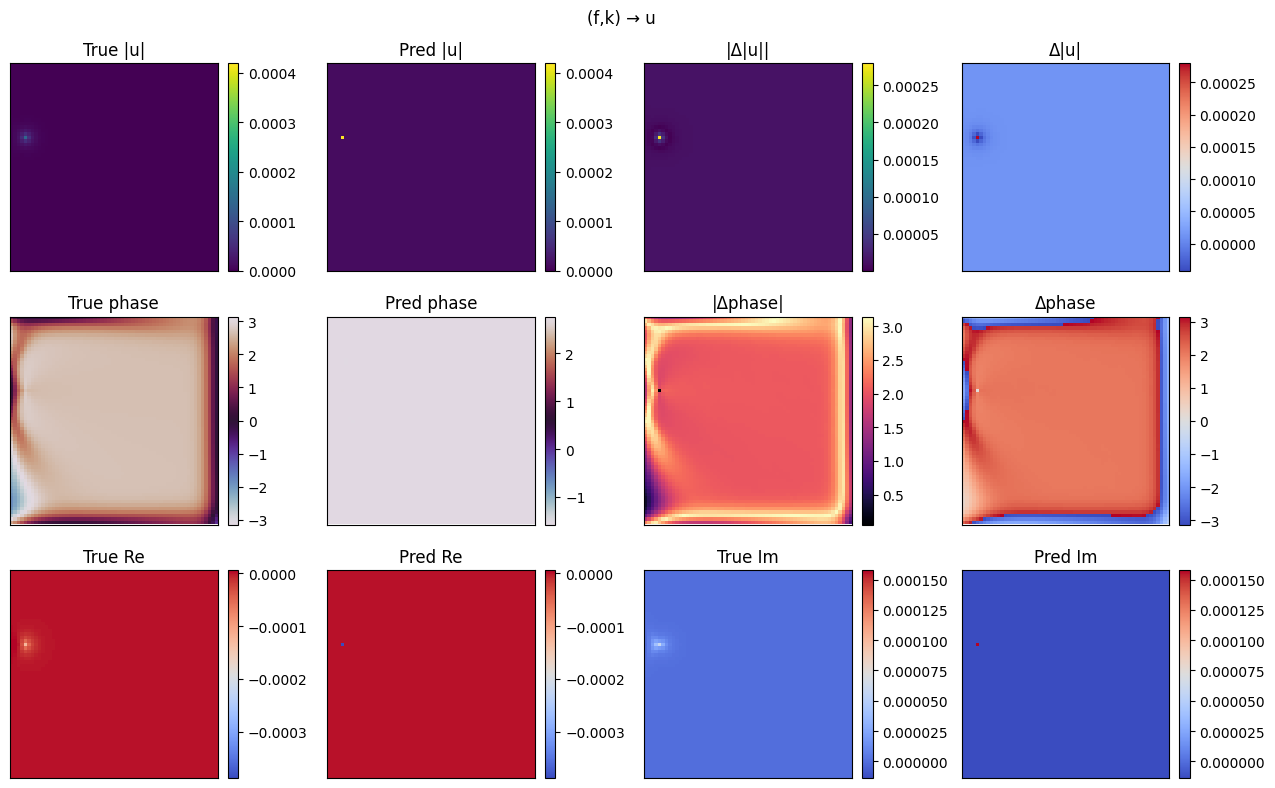

In [26]:
# one sample
idx = 0
x_np = data_direct["x"][idx]           # (3,H,W)
y_np = data_direct["y"][idx]           # (2,H,W) truth
with torch.no_grad():
    pred_np = model_fk2(torch.from_numpy(x_np[None]).float()).cpu().numpy()[0]  # (2,H,W)

compare_fields(y_np, pred_np, title_prefix="(f,k) → u")


How to use (freq transfer)

In [ ]:
idx = 0
x_np = data_transfer["x"][idx]         # (3,H,W) = [Re u_low, Im u_low, k_high-field]
y_np = data_transfer["y"][idx]         # (2,H,W) = u_high (truth)
u_low = x_np[:2]
with torch.no_grad():
    pred_np = T(torch.from_numpy(u_low[None]).float()).cpu().numpy()[0]  # (2,H,W)

compare_fields(y_np, pred_np, title_prefix="(u_low, k_high) → u_high")


3) line cuts (see phase alignment along a row/column)

In [27]:
def linecut(u_true_2ch, u_pred_2ch, row=None, col=None):
    H, W = u_true_2ch.shape[1:]
    if row is None and col is None: row = H//2
    if row is not None:
        t_Re = u_true_2ch[0, row, :]; p_Re = u_pred_2ch[0, row, :]
        t_Im = u_true_2ch[1, row, :]; p_Im = u_pred_2ch[1, row, :]
        x = np.arange(W)
        fig,ax=plt.subplots(2,1, figsize=(8,4), sharex=True)
        ax[0].plot(x, t_Re, label="True Re"); ax[0].plot(x, p_Re, "--", label="Pred Re")
        ax[1].plot(x, t_Im, label="True Im"); ax[1].plot(x, p_Im, "--", label="Pred Im")
        ax[0].legend(); ax[1].legend(); ax[0].set_title(f"Line cut @ row {row}")
        plt.show()
    if col is not None:
        t_Re = u_true_2ch[0, :, col]; p_Re = u_pred_2ch[0, :, col]
        t_Im = u_true_2ch[1, :, col]; p_Im = u_pred_2ch[1, :, col]
        y = np.arange(H)
        fig,ax=plt.subplots(2,1, figsize=(8,4), sharex=True)
        ax[0].plot(y, t_Re, label="True Re"); ax[0].plot(y, p_Re, "--", label="Pred Re")
        ax[1].plot(y, t_Im, label="True Im"); ax[1].plot(y, p_Im, "--", label="Pred Im")
        ax[0].legend(); ax[1].legend(); ax[0].set_title(f"Line cut @ col {col}")
        plt.show()


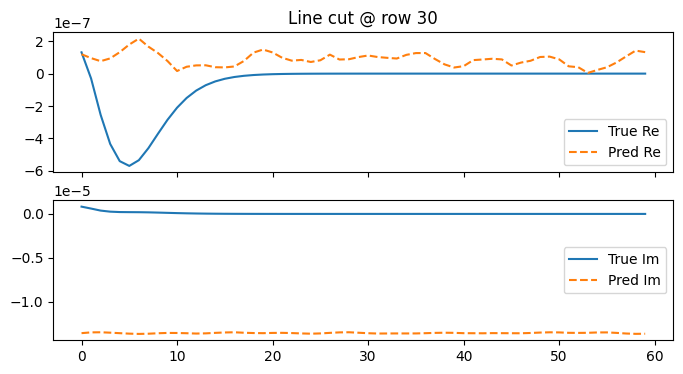

In [28]:
linecut(y_np, pred_np, row=y_np.shape[1]//2)


4) error vs. frequency (transfer map)

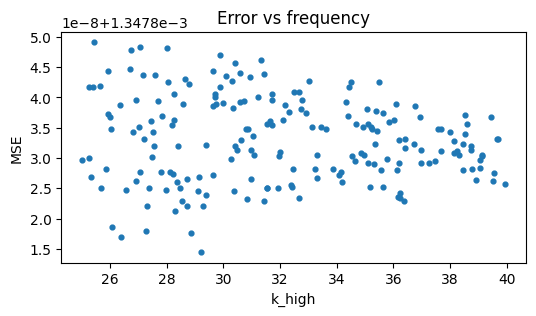

In [29]:
def batch_error_vs_k(model_T, data_transfer, n_samples=200):
    xs = data_transfer["x"][:n_samples]   # (N,3,H,W)
    ys = data_transfer["y"][:n_samples]   # (N,2,H,W)
    ks = xs[:, 2, 0, 0]                   # k_high constant field channel
    errs = []
    with torch.no_grad():
        for i in range(len(xs)):
            u_low = torch.from_numpy(xs[i, :2][None]).float()
            pred  = model_T(u_low).cpu().numpy()[0]
            y     = ys[i]
            err   = np.mean((pred - y)**2)
            errs.append(err)
    return ks, np.array(errs)

ks, errs = batch_error_vs_k(T, data_transfer, n_samples=200)
plt.figure(figsize=(6,3)); plt.scatter(ks, errs, s=12); 
plt.xlabel("k_high"); plt.ylabel("MSE"); plt.title("Error vs frequency"); plt.show()


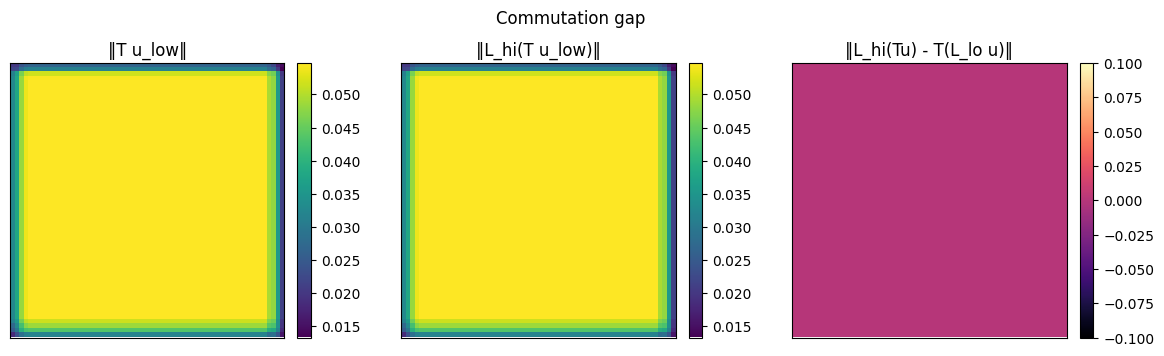

In [30]:
def visualize_commutation(T, u_low_2ch, apply_L_lo, apply_L_hi, title="Commutation gap"):
    """
    u_low_2ch: (2,H,W) numpy
    """
    import torch
    H, W = u_low_2ch.shape[1:]
    u = torch.from_numpy(u_low_2ch[None]).float()
    with torch.no_grad():
        Tu      = T(u).cpu().numpy()[0]              # (2,H,W)
        Lhi_Tu  = apply_L_hi(torch.from_numpy(Tu[None]).float()).cpu().numpy()[0]
        Llo_u   = apply_L_lo(u).cpu().numpy()[0]
        T_Llou  = T(torch.from_numpy(Llo_u[None]).float()).cpu().numpy()[0]
    gap = np.sqrt((Lhi_Tu - T_Llou)**2).sum(axis=0)  # pointwise 2-norm over Re/Im

    fig, axs = plt.subplots(1,3, figsize=(12,3.5))
    imshow(axs[0], np.linalg.norm(Tu, axis=0), "‖T u_low‖")
    imshow(axs[1], np.linalg.norm(Lhi_Tu, axis=0), "‖L_hi(T u_low)‖")
    imshow(axs[2], gap, "‖L_hi(Tu) - T(L_lo u)‖", cmap="magma")
    fig.suptitle(title); plt.tight_layout(); plt.show()

# example (with any one sample)
u_low = data_transfer["x"][0, :2]
visualize_commutation(T, u_low, apply_L_lo, apply_L_hi)


In [31]:
def shade_pml(ax, H, W, pml_thickness):
    t = pml_thickness
    ax.add_patch(plt.Rectangle((0,0), W, t,    fc='none', ec='k', ls='--', lw=0.8))
    ax.add_patch(plt.Rectangle((0,H-t), W, t,  fc='none', ec='k', ls='--', lw=0.8))
    ax.add_patch(plt.Rectangle((0,0), t, H,    fc='none', ec='k', ls='--', lw=0.8))
    ax.add_patch(plt.Rectangle((W-t,0), t, H,  fc='none', ec='k', ls='--', lw=0.8))

# usage inside compare_fields:
# shade_pml(axs[0,0], H, W, pml_thickness=10)
